# Fracture Dataset — Exploratory Data Analysis

Forearm X-ray dataset with 6 categories:
- 3 anatomical regions: **Distal**, **Complete**, **Proximal**
- 2 labels per region: **Fracture** (mit Fraktur) vs **Normal** (normale Anatomie)

In [1]:
import os
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# ── paths ──────────────────────────────────────────────────────────────────
DATA_ROOT = Path("/Users/venthanvigneswaran/Library/Mobile Documents/com~apple~CloudDocs/neueste bilder/Promotion")
IMG_ROOT  = DATA_ROOT / "alle Bilder"
XLSX_PATH = DATA_ROOT / "Fälle .xlsx"

# ── category metadata ──────────────────────────────────────────────────────
CATEGORIES = {
    "Distale UA-Aufnahme mit HG mit Fraktur":          {"region": "distal",   "label": "fracture", "label_id": 1},
    "Distale UA-Aufnahme mit HG normale Anatomie":     {"region": "distal",   "label": "normal",   "label_id": 0},
    "Komplette UA-Aufnahme mit EB und HG mit Fraktur": {"region": "complete", "label": "fracture", "label_id": 1},
    "Komplette UA-Aufnahme mit EB und HG normale Anatomie": {"region": "complete", "label": "normal", "label_id": 0},
    "Proximale UA-Aufnahme mit EB mit Fraktur":        {"region": "proximal", "label": "fracture", "label_id": 1},
    "Proximale UA-Aufnahme mit EB normale Anatomie":   {"region": "proximal", "label": "normal",   "label_id": 0},
}

print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"IMG_ROOT  exists: {IMG_ROOT.exists()}")
print(f"XLSX      exists: {XLSX_PATH.exists()}")

ModuleNotFoundError: No module named 'matplotlib'

## 1. Build Image Index

In [2]:
records = []

for cat_name, meta in CATEGORIES.items():
    cat_dir = IMG_ROOT / cat_name
    if not cat_dir.exists():
        print(f"WARNING: missing {cat_dir}")
        continue
    for case_dir in sorted(cat_dir.iterdir()):
        if not case_dir.is_dir():
            continue
        images = sorted([f for f in case_dir.iterdir()
                         if f.suffix.lower() in (".png", ".jpg", ".jpeg")])
        for img_path in images:
            records.append({
                "path":      str(img_path),
                "case_id":   case_dir.name,
                "category":  cat_name,
                "region":    meta["region"],
                "label":     meta["label"],
                "label_id":  meta["label_id"],
                "series":    img_path.stem,          # e.g. Serie001_Bild0001
            })

df = pd.DataFrame(records)
print(f"Total images : {len(df):,}")
print(f"Total cases  : {df['case_id'].nunique():,}")
df.head()

Total images : 4,806
Total cases  : 2,354


,path,case_id,category,region,label,label_id,series
0,/Users/venthanvigneswaran/Library/Mobile Docum...,2010_007,Distale UA-Aufnahme mit HG mit Fraktur,distal,fracture,1,Serie001_Bild0001
1,/Users/venthanvigneswaran/Library/Mobile Docum...,2011_003,Distale UA-Aufnahme mit HG mit Fraktur,distal,fracture,1,Serie001_Bild0001
2,/Users/venthanvigneswaran/Library/Mobile Docum...,2011_005,Distale UA-Aufnahme mit HG mit Fraktur,distal,fracture,1,Serie001_Bild0001
3,/Users/venthanvigneswaran/Library/Mobile Docum...,2011_005,Distale UA-Aufnahme mit HG mit Fraktur,distal,fracture,1,Serie002_Bild0001
4,/Users/venthanvigneswaran/Library/Mobile Docum...,2011_006,Distale UA-Aufnahme mit HG mit Fraktur,distal,fracture,1,Serie001_Bild0001


## 2. Category Overview

In [3]:
overview = (
    df.groupby(["region", "label"])
      .agg(
          cases  = ("case_id", "nunique"),
          images = ("path",    "count"),
      )
      .reset_index()
)
overview["imgs_per_case"] = (overview["images"] / overview["cases"]).round(2)
print(overview.to_string(index=False))

  region    label  cases  images  imgs_per_case
complete fracture    465     950           2.04
complete   normal    227     481           2.12
  distal fracture    512    1030           2.01
  distal   normal    623    1340           2.15
proximal fracture    185     352           1.90
proximal   normal    350     653           1.87


## 3. Class Distribution (Binary: fracture vs normal)

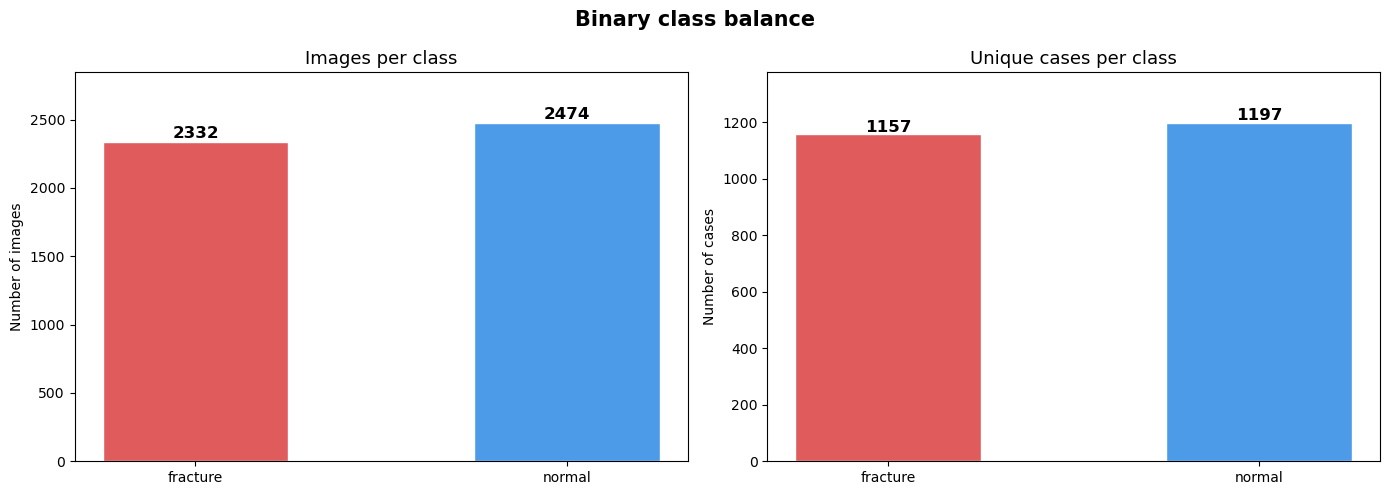

Fracture/Normal case ratio: 0.97  (balanced)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── by image count ─────────────────────────────────────────────────────────
label_img = df.groupby("label")["path"].count()
axes[0].bar(label_img.index, label_img.values,
            color=["#e05c5c", "#4c9be8"], edgecolor="white", width=0.5)
for i, v in enumerate(label_img.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Images per class", fontsize=13)
axes[0].set_ylabel("Number of images")
axes[0].set_ylim(0, label_img.max() * 1.15)

# ── by case count ──────────────────────────────────────────────────────────
label_case = df.drop_duplicates("case_id").groupby("label")["case_id"].count()
axes[1].bar(label_case.index, label_case.values,
            color=["#e05c5c", "#4c9be8"], edgecolor="white", width=0.5)
for i, v in enumerate(label_case.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Unique cases per class", fontsize=13)
axes[1].set_ylabel("Number of cases")
axes[1].set_ylim(0, label_case.max() * 1.15)

fig.suptitle("Binary class balance", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

ratio = label_case["fracture"] / label_case["normal"]
print(f"Fracture/Normal case ratio: {ratio:.2f}  ({'balanced' if 0.8 < ratio < 1.2 else 'imbalanced'})")

## 4. Class Distribution by Region

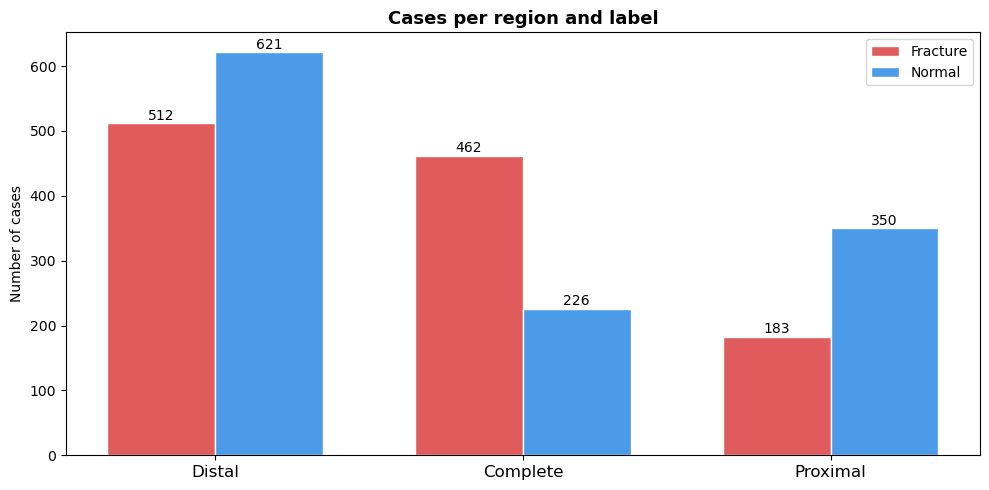

In [5]:
region_order = ["distal", "complete", "proximal"]
pivot = (
    df.drop_duplicates("case_id")
      .groupby(["region", "label"])["case_id"]
      .count()
      .unstack(fill_value=0)
      .reindex(region_order)
)

x = np.arange(len(pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, pivot["fracture"], width, label="Fracture", color="#e05c5c", edgecolor="white")
bars2 = ax.bar(x + width/2, pivot["normal"],   width, label="Normal",   color="#4c9be8", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([r.capitalize() for r in region_order], fontsize=12)
ax.set_ylabel("Number of cases")
ax.set_title("Cases per region and label", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Images per Case Distribution

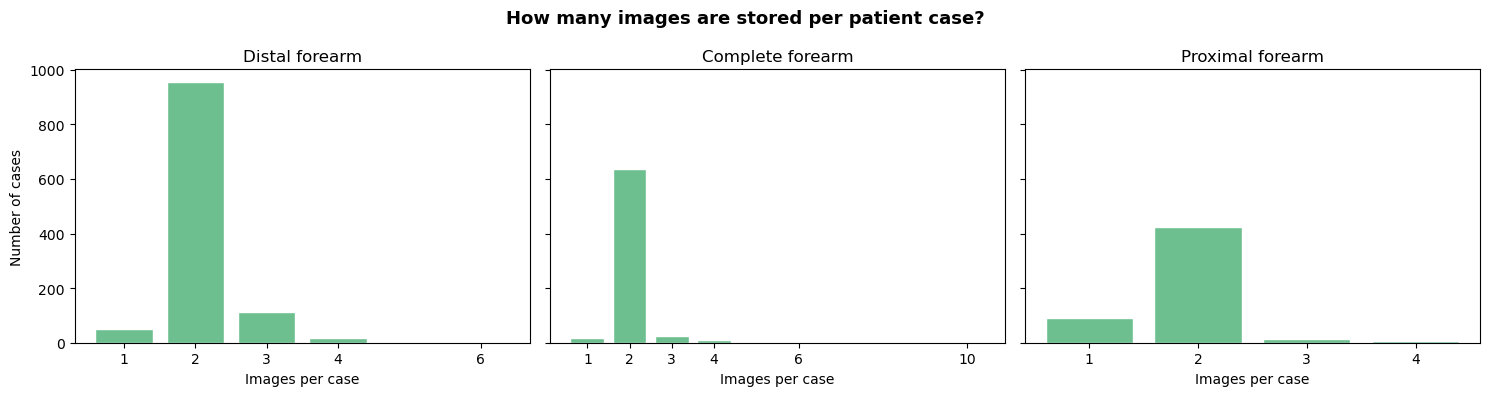

count    2362.000000
mean        2.034716
std         0.488388
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max        10.000000

Cases with only 1 image : 158
Cases with 2+ images   : 2204


In [6]:
imgs_per_case = df.groupby(["case_id", "region", "label"])["path"].count().reset_index()
imgs_per_case.columns = ["case_id", "region", "label", "n_images"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, region in zip(axes, region_order):
    subset = imgs_per_case[imgs_per_case["region"] == region]
    counts = subset["n_images"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#6dbf8f", edgecolor="white")
    ax.set_title(f"{region.capitalize()} forearm", fontsize=12)
    ax.set_xlabel("Images per case")
    ax.set_ylabel("Number of cases" if ax == axes[0] else "")
    ax.set_xticks(counts.index)

fig.suptitle("How many images are stored per patient case?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(imgs_per_case["n_images"].describe().to_string())
print(f"\nCases with only 1 image : {(imgs_per_case['n_images'] == 1).sum()}")
print(f"Cases with 2+ images   : {(imgs_per_case['n_images'] >= 2).sum()}")

## 6. Image Resolution Analysis

In [7]:
# Sample up to 200 images per category for speed
SAMPLE_N = 200

sample_df = (
    df.groupby("category", group_keys=False)
      .apply(lambda g: g.sample(min(SAMPLE_N, len(g)), random_state=42))
)

widths, heights = [], []
for path in sample_df["path"]:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        widths.append(None)
        heights.append(None)

sample_df = sample_df.copy()
sample_df["width"]  = widths
sample_df["height"] = heights
sample_df = sample_df.dropna(subset=["width", "height"])
sample_df[["width", "height"]] = sample_df[["width", "height"]].astype(int)

print("Width  stats:", sample_df["width"].describe().to_dict())
print("Height stats:", sample_df["height"].describe().to_dict())

unique_sizes = sample_df.groupby(["width", "height"]).size().reset_index(name="count").sort_values("count", ascending=False)
print(f"\nUnique resolutions found (top 10):")
print(unique_sizes.head(10).to_string(index=False))

/var/folders/2y/9nyfcd9j3_dgpcxwsvt5g8300000gn/T/ipykernel_3655/1068811451.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(SAMPLE_N, len(g)), random_state=42))


Width  stats: {'count': 1200.0, 'mean': 893.8941666666667, 'std': 391.421571972143, 'min': 272.0, '25%': 640.0, '50%': 784.0, '75%': 1056.0, 'max': 4248.0}
Height stats: {'count': 1200.0, 'mean': 1352.1875, 'std': 503.3006195158988, 'min': 464.0, '25%': 976.0, '50%': 1236.0, '75%': 1664.0, 'max': 3480.0}

Unique resolutions found (top 10):
 width  height  count
  2016    2700      5
   864     896      3
   784    1896      3
   752    1040      3
  1008    1350      3
   672    1424      3
   496     816      3
  1216     896      3
   816    1216      3
  2970    2100      3


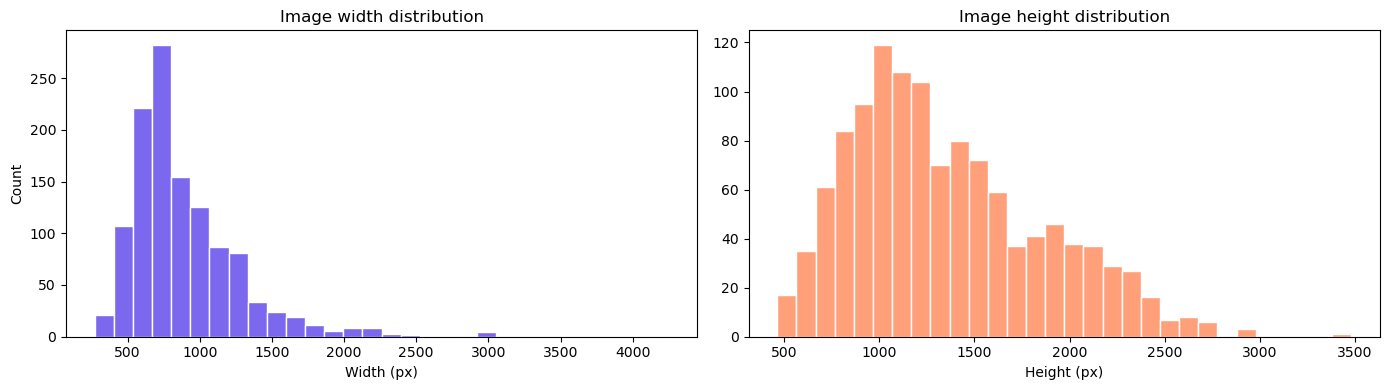

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_df["width"],  bins=30, color="#7b68ee", edgecolor="white")
axes[0].set_title("Image width distribution",  fontsize=12)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(sample_df["height"], bins=30, color="#ffa07a", edgecolor="white")
axes[1].set_title("Image height distribution", fontsize=12)
axes[1].set_xlabel("Height (px)")

plt.tight_layout()
plt.show()

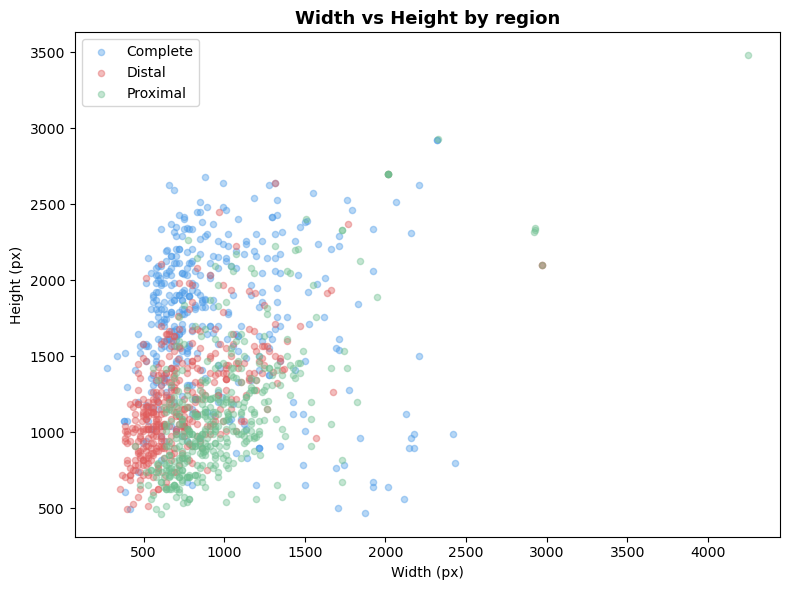

In [9]:
# Scatter: width vs height coloured by region
region_colors = {"distal": "#e05c5c", "complete": "#4c9be8", "proximal": "#6dbf8f"}

fig, ax = plt.subplots(figsize=(8, 6))
for region, grp in sample_df.groupby("region"):
    ax.scatter(grp["width"], grp["height"],
               alpha=0.4, s=20, label=region.capitalize(),
               color=region_colors[region])

ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Width vs Height by region", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sample Image Visualisation

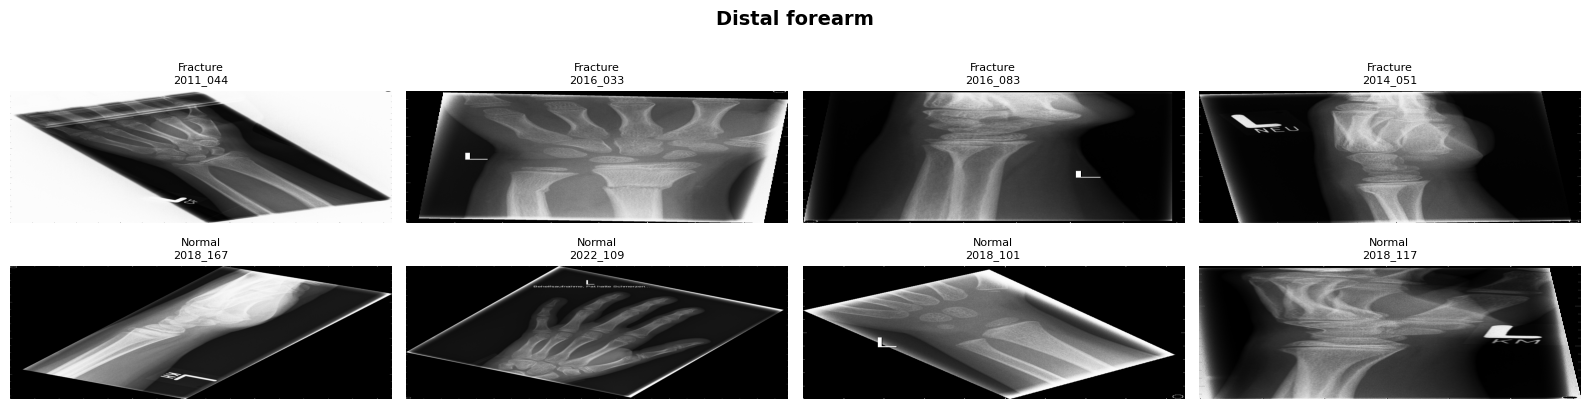

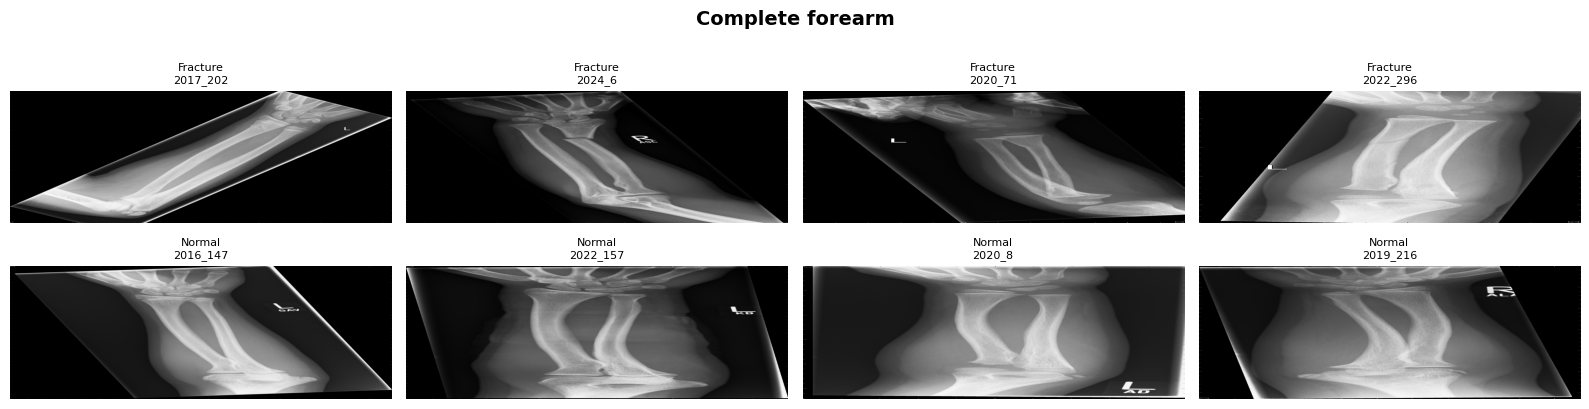

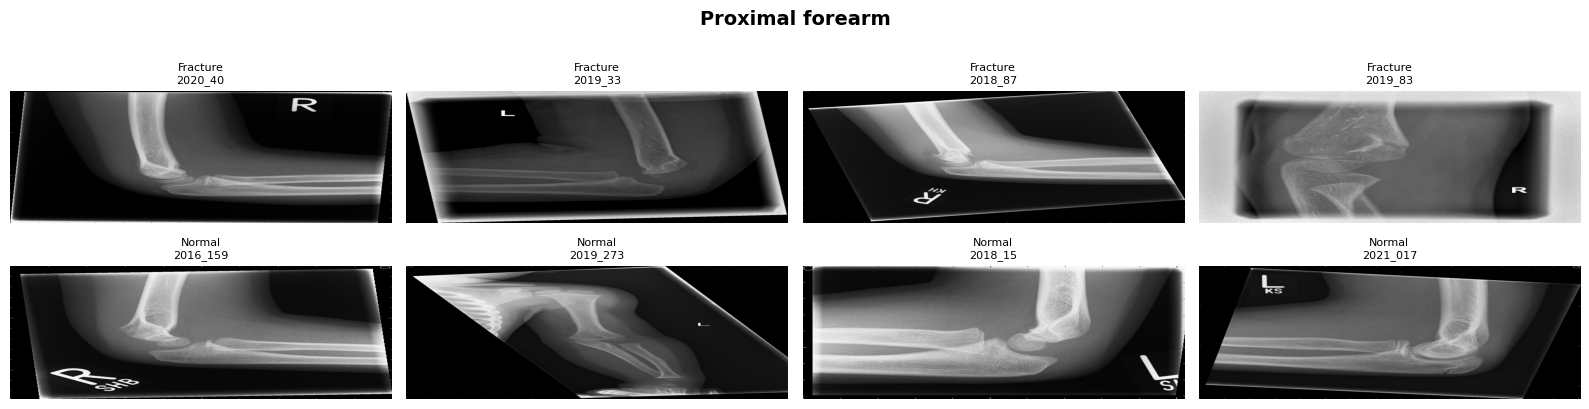

In [10]:
def show_samples(df, region, n=4, figsize=(16, 4)):
    """Show n fracture and n normal samples side-by-side for a given region."""
    fig, axes = plt.subplots(2, n, figsize=figsize)
    fig.suptitle(f"{region.capitalize()} forearm", fontsize=14, fontweight="bold", y=1.01)

    for col, label in enumerate(["fracture", "normal"]):
        subset = df[(df["region"] == region) & (df["label"] == label)]
        samples = subset.sample(min(n, len(subset)), random_state=42)
        row_axes = axes[col]
        for ax, (_, row) in zip(row_axes, samples.iterrows()):
            img = Image.open(row["path"]).convert("L")  # grayscale
            ax.imshow(img, cmap="gray", aspect="auto")
            ax.set_title(f"{label.capitalize()}\n{row['case_id']}", fontsize=8)
            ax.axis("off")
        # blank leftover axes
        for ax in row_axes[len(samples):]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

for region in region_order:
    show_samples(df, region, n=4)

## 8. Pixel Intensity Statistics (Brightness / Contrast)

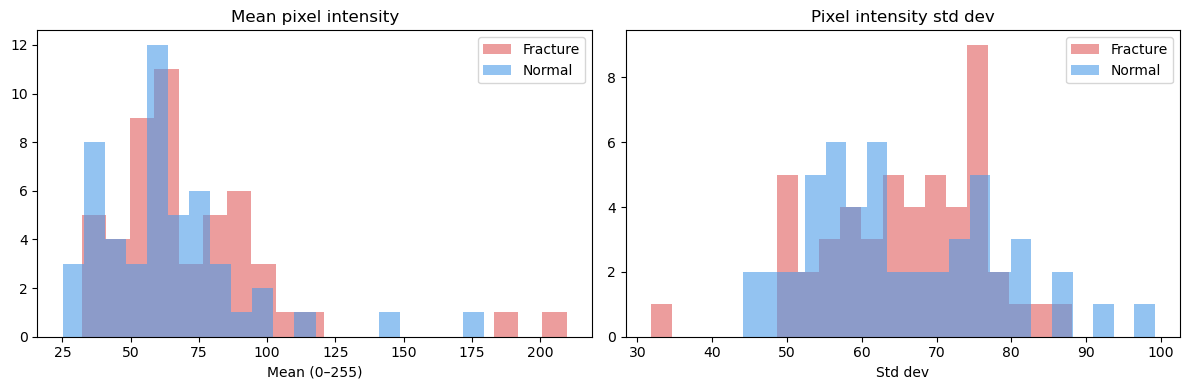

          mean                                              std              \
         count  mean   std   min   25%   50%   75%    max count  mean   std   
label                                                                         
fracture  50.0  72.5  32.3  32.0  55.1  63.2  85.8  209.8  50.0  65.7  10.8   
normal    50.0  63.9  28.1  25.1  44.2  59.8  73.2  179.5  50.0  65.6  12.5   

                                        
           min   25%   50%   75%   max  
label                                   
fracture  31.8  58.5  66.2  74.5  88.1  
normal    44.2  56.1  62.4  75.9  99.2  


In [11]:
# Sample 50 images per label for intensity stats
intensity_records = []
INTENSITY_SAMPLE = 50

for label in ["fracture", "normal"]:
    subset = df[df["label"] == label].sample(INTENSITY_SAMPLE, random_state=42)
    for _, row in subset.iterrows():
        try:
            arr = np.array(Image.open(row["path"]).convert("L"), dtype=np.float32)
            intensity_records.append({
                "label":  label,
                "mean":   arr.mean(),
                "std":    arr.std(),
                "min":    arr.min(),
                "max":    arr.max(),
            })
        except Exception:
            pass

intensity_df = pd.DataFrame(intensity_records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in zip(["fracture", "normal"], ["#e05c5c", "#4c9be8"]):
    grp = intensity_df[intensity_df["label"] == label]
    axes[0].hist(grp["mean"], bins=20, alpha=0.6, label=label.capitalize(), color=color)
    axes[1].hist(grp["std"],  bins=20, alpha=0.6, label=label.capitalize(), color=color)

axes[0].set_title("Mean pixel intensity",    fontsize=12)
axes[0].set_xlabel("Mean (0–255)")
axes[0].legend()
axes[1].set_title("Pixel intensity std dev", fontsize=12)
axes[1].set_xlabel("Std dev")
axes[1].legend()

plt.tight_layout()
plt.show()

print(intensity_df.groupby("label")[["mean", "std"]].describe().round(1))

## 9. Metadata Excel Inspection

In [12]:
xlsx = pd.read_excel(XLSX_PATH)
print(f"Shape: {xlsx.shape}")
print(f"\nColumns:\n{xlsx.columns.tolist()}")
xlsx.head(10)

Shape: (3710, 15)

Columns:
['NAME', 'VORNAME', 'GEBDAT', 'PID', 'GESCHLECHT', 'UNTERSUCHUNG', 'Fraktur?', 'LOKALISATION', 'ZEITPUNKT', 'Nummer', 'Unnamed: 10', 'PID_ZEITPUNKT', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']


,NAME,VORNAME,GEBDAT,PID,GESCHLECHT,UNTERSUCHUNG,Fraktur?,LOKALISATION,ZEITPUNKT,Nummer,Unnamed: 10,PID_ZEITPUNKT,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Kuz,Esila-Sibel,2015-08-10 00:00:00,1463548.0,NaN,Unterarm,Ja,NaN,2024-11-16 00:00:00,2024_1,NaN,1463548_16112024,NaN,NaN,NaN
1,Mock,Elias,2010-07-09 00:00:00,1203229.0,NaN,Unterarm,Ja,NaN,2024-11-12 00:00:00,2024_2,NaN,1203229_12112024,NaN,NaN,NaN
2,Hoogt,Emilia,2008-10-13 00:00:00,1426905.0,NaN,Handgelenk,Nein,NaN,2024-11-12 00:00:00,2024_3,NaN,1426905_12112024,NaN,NaN,NaN
3,Streller,Frederik,2010-07-10 00:00:00,1212779.0,NaN,Handgelenk,Nein,NaN,2024-11-12 00:00:00,2024_4,NaN,1212779_12112024,NaN,NaN,NaN
4,Derksen,Lea,2011-02-06 00:00:00,1144836.0,NaN,Handgelenk,Nein,NaN,2024-11-12 00:00:00,2024_5,NaN,1144836_12112024,NaN,NaN,NaN
5,Gerhard,Samuel Laurin,2007-07-08 00:00:00,1011533.0,NaN,Unterarm,Ja,NaN,2024-08-21 00:00:00,2024_6,NaN,1011533_21082024,NaN,NaN,NaN
6,Herrmann,Merle,2016-02-26 00:00:00,1339510.0,NaN,Handgelenk,Ja,NaN,2024-10-16 00:00:00,2024_7,NaN,1339510_16102024,NaN,NaN,NaN
7,Stauß,Jonathan,2017-08-11 00:00:00,1641018.0,NaN,Unterarm,Ja,NaN,2024-08-14 00:00:00,2024_8,NaN,1641018_14082024,NaN,NaN,NaN
8,Wagner,Anna,2016-08-16 00:00:00,1356700.0,NaN,Handgelenk,Ja,NaN,2024-11-10 00:00:00,2024_9,NaN,1356700_10112024,NaN,NaN,NaN
9,Di Micco,Alejandro André,2010-10-31 00:00:00,1125488.0,NaN,Handgelenk,Nein,NaN,2024-11-09 00:00:00,2024_10,NaN,1125488_09112024,NaN,NaN,NaN


In [13]:
# Basic stats and missing value check
print("Missing values per column:")
print(xlsx.isnull().sum().to_string())
print()
xlsx.describe(include="all")

Missing values per column:
NAME              587
VORNAME           587
GEBDAT            587
PID               587
GESCHLECHT       1709
UNTERSUCHUNG      587
Fraktur?          587
LOKALISATION     2387
ZEITPUNKT         587
Nummer            587
Unnamed: 10      3710
PID_ZEITPUNKT     587
Unnamed: 12      3710
Unnamed: 13      3709
Unnamed: 14      3703



,NAME,VORNAME,GEBDAT,PID,GESCHLECHT,UNTERSUCHUNG,Fraktur?,LOKALISATION,ZEITPUNKT,Nummer,Unnamed: 10,PID_ZEITPUNKT,Unnamed: 12,Unnamed: 13,Unnamed: 14
count,3123,3123,3123,3.123000e+03,2001,3123,3123,1323,3123,3123,0.0,3123,0.0,1.0,7.0
unique,2012,1745,2107,NaN,3,3,2,5,1746,3122,NaN,2814,NaN,NaN,7.0
top,Müller,Leon,2007-09-30 00:00:00,NaN,m,Handgelenk,Ja,-,2021-09-02 00:00:00,2023_337,NaN,929115_06102022,NaN,NaN,31883.0
freq,25,21,13,NaN,1103,1431,1598,749,9,2,NaN,6,NaN,NaN,1.0
mean,NaN,NaN,NaN,1.251126e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN
std,NaN,NaN,NaN,2.145246e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,4.376590e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN
25%,NaN,NaN,NaN,1.088724e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN
50%,NaN,NaN,NaN,1.237777e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN
75%,NaN,NaN,NaN,1.426760e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN


## 10. Year Distribution of Cases

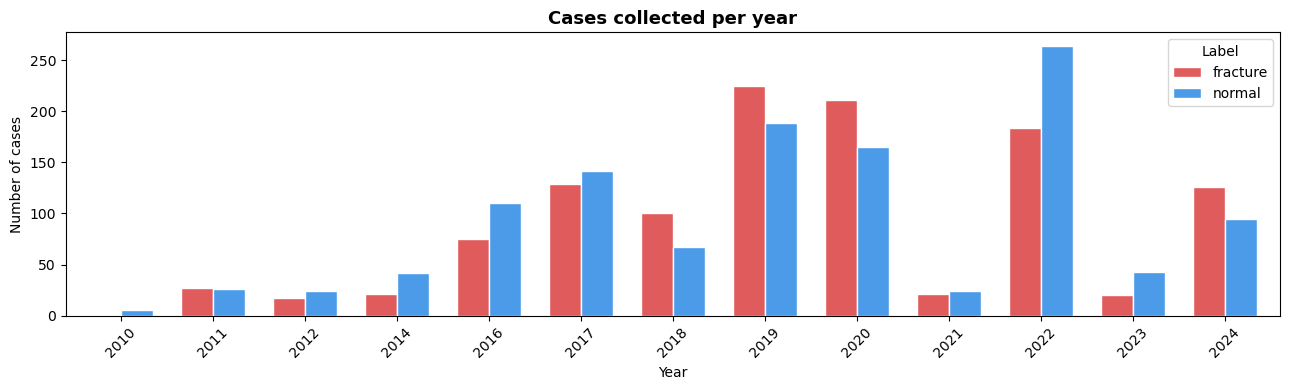

In [14]:
# Extract year from case_id (format: YYYY_NNN)
cases_df = df.drop_duplicates("case_id").copy()
cases_df["year"] = cases_df["case_id"].str.extract(r"^(\d{4})").astype(int, errors="ignore")

year_pivot = (
    cases_df.groupby(["year", "label"])["case_id"]
      .count()
      .unstack(fill_value=0)
      .sort_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
year_pivot.plot(kind="bar", ax=ax, color=["#e05c5c", "#4c9be8"], edgecolor="white", width=0.7)
ax.set_title("Cases collected per year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of cases")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Label")
plt.tight_layout()
plt.show()

## 11. Multi-image Cases — Which Series Numbers Exist?

In [15]:
# Extract series number from filename (Serie001, Serie002, ...)
df["serie_num"] = df["series"].str.extract(r"Serie(\d+)").astype(int, errors="ignore")

serie_counts = df["serie_num"].value_counts().sort_index()
print("Images per series number:")
print(serie_counts.to_string())

# What percentage of cases have ≥ 2 series?
case_series_max = df.groupby("case_id")["serie_num"].max()
print(f"\nCases with only Serie001 (1 view) : {(case_series_max == 1).sum():,}")
print(f"Cases with Serie002  (2 views)    : {(case_series_max == 2).sum():,}")
print(f"Cases with Serie003+ (3+ views)   : {(case_series_max >= 3).sum():,}")

Images per series number:
serie_num
0            1
1         2373
2         2127
3          234
4           25
5            6
6            2
7            1
8            1
1000        14
1001         2
1002         2
1003         1
1004         1
2001         8
2002         2
567801       6

Cases with only Serie001 (1 view) : 178
Cases with Serie002  (2 views)    : 1,919
Cases with Serie003+ (3+ views)   : 257


## 12. Summary & Recommendations

In [16]:
n_fracture = cases_df[cases_df["label"] == "fracture"].shape[0]
n_normal   = cases_df[cases_df["label"] == "normal"].shape[0]
n_total    = len(cases_df)

print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"Total cases            : {n_total:,}")
print(f"  Fracture cases       : {n_fracture:,} ({n_fracture/n_total*100:.1f}%)")
print(f"  Normal cases         : {n_normal:,} ({n_normal/n_total*100:.1f}%)")
print(f"Total images           : {len(df):,}")
print(f"Average imgs per case  : {len(df)/n_total:.2f}")
print()
print("NEXT STEPS")
print("-" * 55)
print("1. dataset.py  → build train/val/test split at CASE level")
print("   (80 / 10 / 10), stratified by region × label")
print()
print("2. For multi-image cases decide strategy:")
print("   a) Use all images independently (data augmentation via views)")
print("   b) Use only Serie001 (1 image per case, cleanest)")
print("   c) MIL — treat each case as a bag of images")
print()
print("3. Preprocessing pipeline:")
print("   - Resize to 512×512 or 384×384")
print("   - Convert to 3-channel (grayscale → RGB repeat)")
print("   - Normalize with ImageNet mean/std")
print("   - Augment: random flip, rotation ±15°, brightness jitter")

DATASET SUMMARY
Total cases            : 2,354
  Fracture cases       : 1,157 (49.2%)
  Normal cases         : 1,197 (50.8%)
Total images           : 4,806
Average imgs per case  : 2.04

NEXT STEPS
-------------------------------------------------------
1. dataset.py  → build train/val/test split at CASE level
   (80 / 10 / 10), stratified by region × label

2. For multi-image cases decide strategy:
   a) Use all images independently (data augmentation via views)
   b) Use only Serie001 (1 image per case, cleanest)
   c) MIL — treat each case as a bag of images

3. Preprocessing pipeline:
   - Resize to 512×512 or 384×384
   - Convert to 3-channel (grayscale → RGB repeat)
   - Normalize with ImageNet mean/std
   - Augment: random flip, rotation ±15°, brightness jitter
